In [16]:
# Add the parent directory to Python path so Jupyter can find your package
import importlib
import os
import sys

notebook_dir = os.path.abspath('')
parent_dir = os.path.dirname(notebook_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"Added {parent_dir} to Python path")

# Import and reload so notebook picks up latest code changes
import causal_forecast
import causal_forecast.typing
import causal_forecast.seasonality
import causal_forecast.metrics
import causal_forecast.utils
import causal_forecast.glm_models
import causal_forecast.model_summary
import causal_forecast.core
from causal_forecast import (
    plot_time_series,
    plot_forecast_comparison,
    plot_seasonal_decomposition,
    plot_counterfactual_timeseries
)
for mod in (
    causal_forecast.typing,
    causal_forecast.seasonality,
    causal_forecast.metrics,
    causal_forecast.utils,
    causal_forecast.glm_models,
    causal_forecast.model_summary,
    causal_forecast.core,
    causal_forecast,
):
    importlib.reload(mod)

from causal_forecast import CausalForecaster
from dataclasses import fields as dc_fields
from causal_forecast.utils import FittedNodeModel

print(f"Loaded causal_forecast from: {causal_forecast.__file__}")
print(f"model_type supported: {'model_type' in CausalForecaster.__init__.__code__.co_varnames}")
print(f"FittedNodeModel fields: {[f.name for f in dc_fields(FittedNodeModel)]}")

Loaded causal_forecast from: /Users/jamel/Documents/Documents - Jamel’s MacBook Pro/CausalForecasting/causal_forecast/__init__.py
model_type supported: True
FittedNodeModel fields: ['model', 'variable_type', 'label_encoder', 'categories', 'one_hot_encoder', 'one_hot_feature_names', 'model_backend', 'feature_names']


In [17]:
# Create mixed-type sample time series data
import pandas as pd
import numpy as np
import networkx as nx
from causal_forecast import detect_variable_types
# CausalForecaster imported in cell 0 (with reload)

In [18]:
horizon_length = 30

In [19]:
import networkx as nx

G = nx.DiGraph()

G.add_edges_from([
    ("marketing_spend", "website_traffic"),
    ("marketing_spend", "sales"),
    ("website_traffic", "sales"),
])

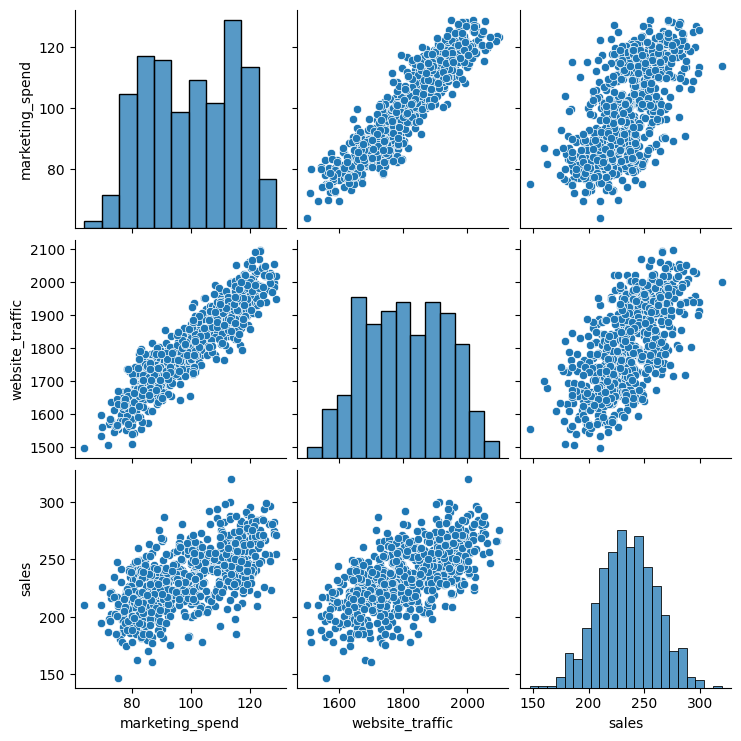

In [29]:
import seaborn as sns
sns.pairplot(df)

In [20]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_days = 730

dates = pd.date_range(
    start="2023-01-01",
    periods=n_days,
    freq="D"
)

marketing = (
    100
    + 20 * np.sin(2 * np.pi * np.arange(n_days) / 30)
    + np.random.normal(0, 5, n_days)
)

traffic = (
    1000
    + 8 * marketing
    + np.random.normal(0, 50, n_days)
)

sales = (
    50
    + 0.4 * marketing
    + 0.08 * traffic
    + np.random.normal(0, 20, n_days)
)

df = pd.DataFrame({
    "timestamp": dates,
    "marketing_spend": marketing,
    "website_traffic": traffic,
    "sales": sales,
})

print(df.head())

   timestamp  marketing_spend  website_traffic       sales
0 2023-01-01       102.483571      1829.660829  234.597175
1 2023-01-02       103.466912      1778.816660  209.206133
2 2023-01-03       111.373176      1911.398042  243.280648
3 2023-01-04       119.370854      1869.837654  230.324945
4 2023-01-05       113.692130      1960.994819  240.745968


In [21]:
forecaster = CausalForecaster(
    data=df,
    graph=G,
    target='sales',
    time_column='timestamp',
    forecast_horizon=30,
    lookback_periods=7,
)

forecaster.fit()

future_predictions = forecaster.predict(steps=30)
print("\nFuture predictions:\n", future_predictions.head())

Training model for node: marketing_spend (continuous, random_forest)
Training model for node: website_traffic (continuous, random_forest)
Training model for node: sales (continuous, random_forest)

Future predictions:
    timestamp  marketing_spend  website_traffic       sales
0 2024-12-31       115.467483      1910.264780  251.777644
1 2025-01-01       116.018289      1941.085596  248.656573
2 2025-01-02       116.249008      1916.214955  252.646156
3 2025-01-03       115.670569      1924.614240  243.508579
4 2025-01-04       109.974175      1877.013205  249.138504


In [22]:
baseline_metrics = forecaster.evaluate(holdout_steps=horizon_length)
baseline_metrics

,variable_type,mae,mse,rmse,mape
variable,,,,,
marketing_spend,continuous,12.759462,307.052740,17.522920,12.006459
website_traffic,continuous,117.763723,23857.108909,154.457466,6.254871
sales,continuous,24.163802,907.041384,30.117128,9.928868


In [31]:
forecaster.summarize_model('marketing_spend')

,node,variable_type,model_backend,feature,importance
0,marketing_spend,continuous,random_forest,marketing_spend_lag_1,0.782897
1,marketing_spend,continuous,random_forest,marketing_spend_lag_7,0.052730
2,marketing_spend,continuous,random_forest,marketing_spend_lag_2,0.039932
3,marketing_spend,continuous,random_forest,marketing_spend_lag_6,0.034133
4,marketing_spend,continuous,random_forest,marketing_spend_lag_3,0.023788
5,marketing_spend,continuous,random_forest,marketing_spend_lag_4,0.018831
6,marketing_spend,continuous,random_forest,marketing_spend_lag_5,0.018295
7,marketing_spend,continuous,random_forest,day,0.013453
8,marketing_spend,continuous,random_forest,month,0.008211
9,marketing_spend,continuous,random_forest,dayofweek,0.006394


/var/folders/jk/5pvh3_7x019cjd3ls0bkbbhh0000gn/T/ipykernel_22501/2794274046.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


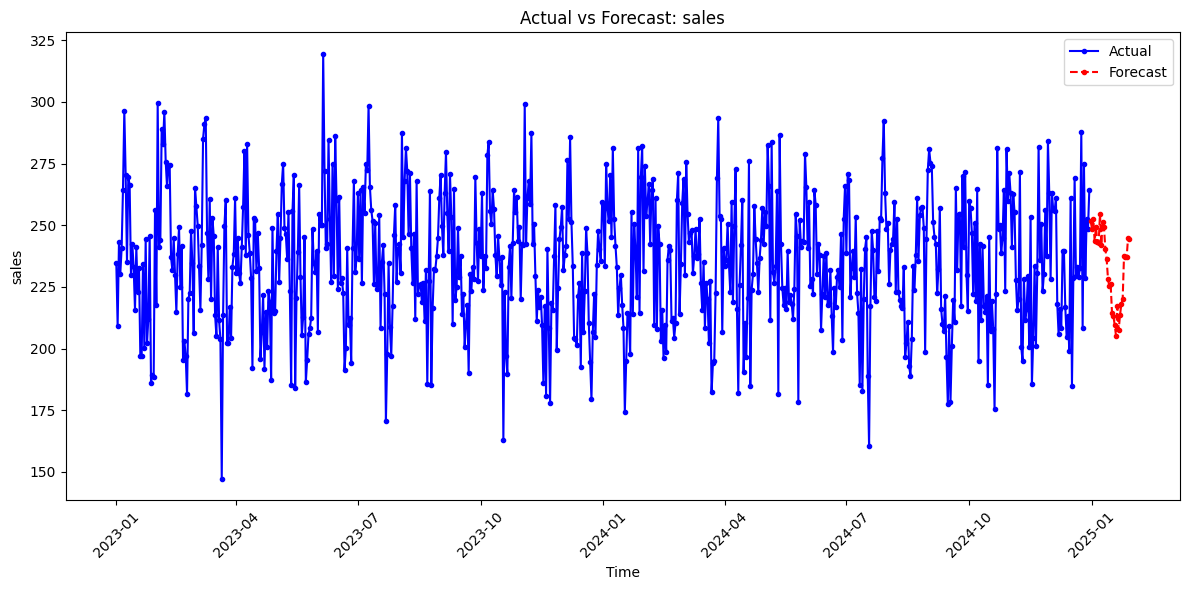

In [24]:
# Compare actual vs forecast
fig = plot_forecast_comparison(df, future_predictions, 'timestamp', 'sales')
fig.show()


In [27]:

counterfactual_predictions = forecaster.run_counterfactual(
    interventions={'website_traffic': [120] * 12 + [120] * (horizon_length - 12)},
    steps=horizon_length,
)

/var/folders/jk/5pvh3_7x019cjd3ls0bkbbhh0000gn/T/ipykernel_22501/739833335.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


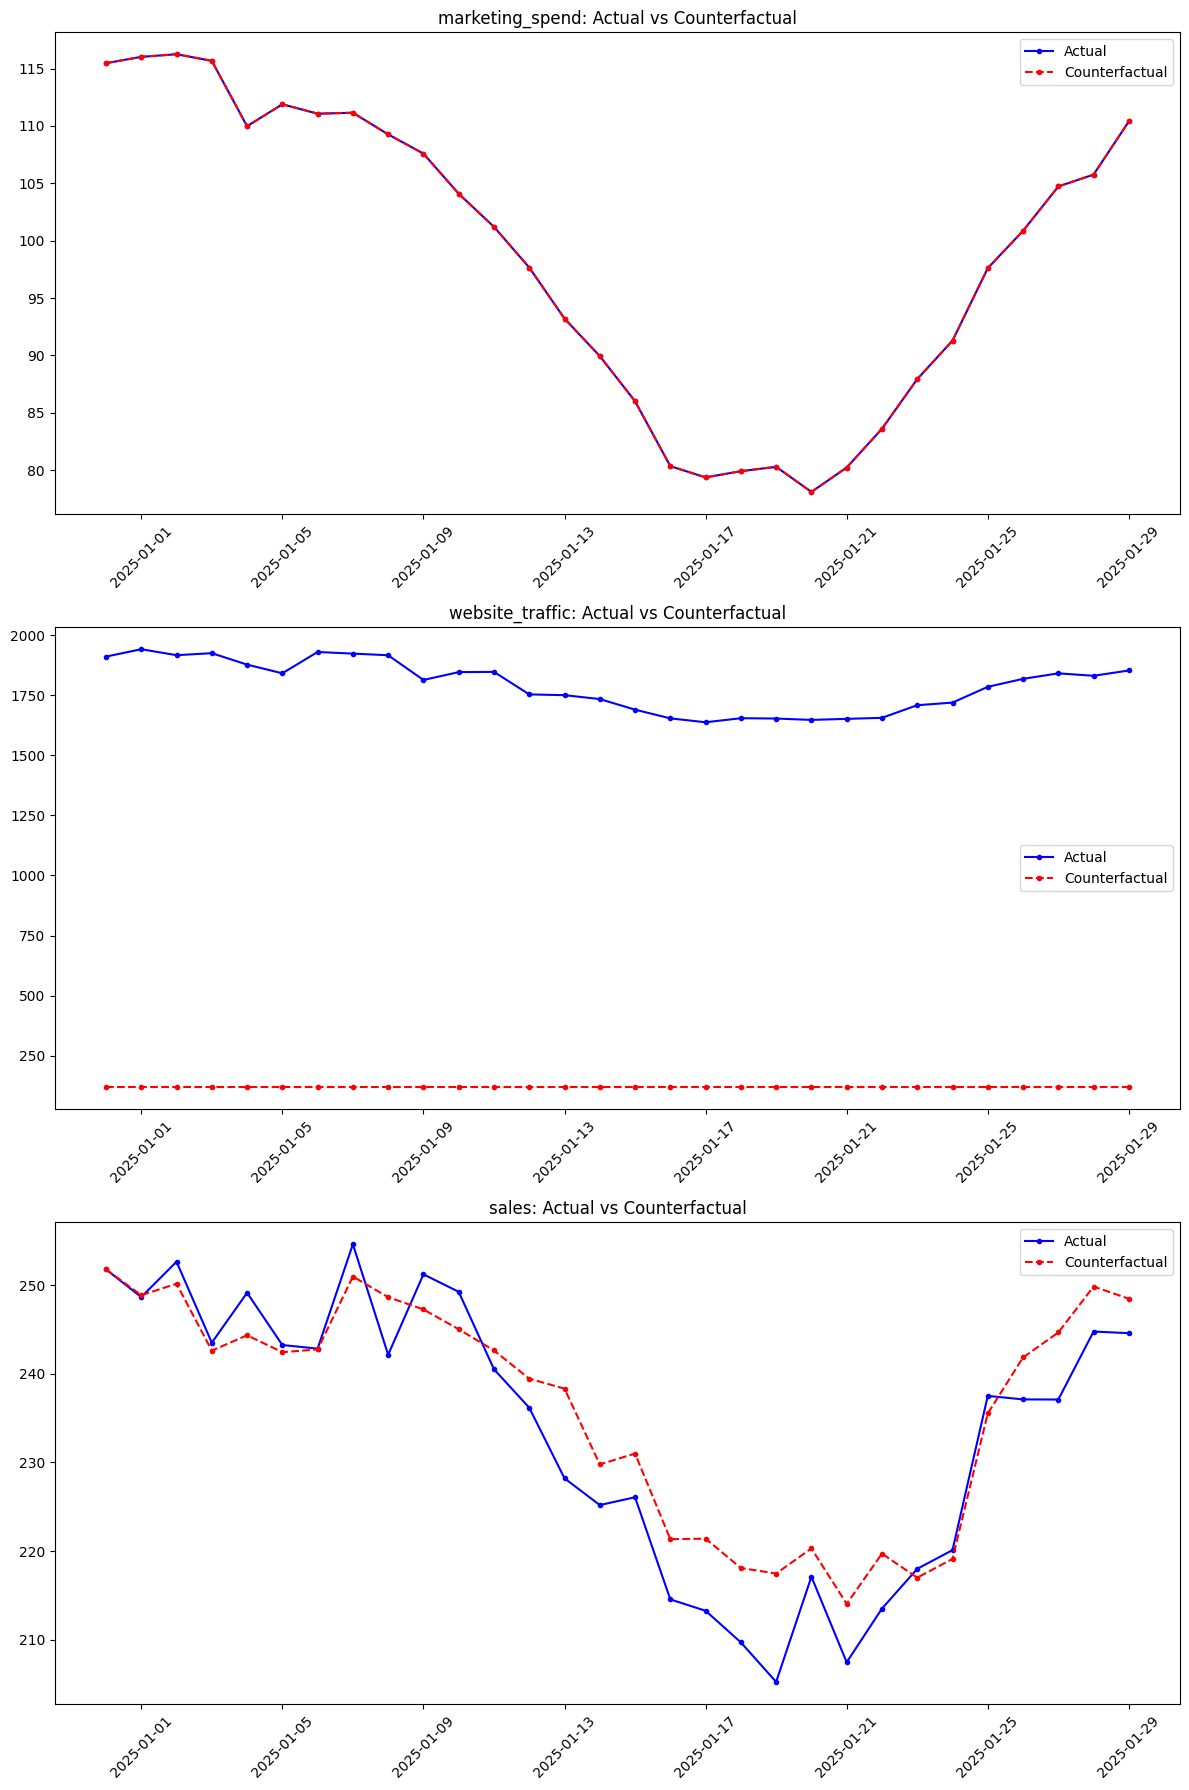

In [28]:

# Compare actual vs counterfactual predictions
fig =  plot_counterfactual_timeseries(
    future_predictions, 
    counterfactual_predictions, 
    'timestamp',
    G.nodes()
)
fig.show()